# Problem 1: Conveyor belt and luggage

## Import the libraries





In [1]:
import os
import numpy as np
np.set_printoptions(suppress=True,precision=2)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Initialize the data and make the x matrix

In [2]:
Data = np.array([
    [1, 10, 4],
    [2, 10, 5],
    [3, 11, 7],
    [4, 12, 11],
    [5, 13, 12],
    [6, 14, 14],
    [7, 15, 17],
    [8, 16, 18],
    [9, 17, 16],
    [10, 18, 15],
    [11, 20, 12]
])

SlNo = Data[:, 0]
Speed = Data[:, 1]
Luggages = Data[:, 2]

X = np.column_stack((np.ones(len(Speed)), Speed, Speed**2))
print("The X",X)
Y = Luggages
print("The Y",Y)

The X [[  1.  10. 100.]
 [  1.  10. 100.]
 [  1.  11. 121.]
 [  1.  12. 144.]
 [  1.  13. 169.]
 [  1.  14. 196.]
 [  1.  15. 225.]
 [  1.  16. 256.]
 [  1.  17. 289.]
 [  1.  18. 324.]
 [  1.  20. 400.]]
The Y [ 4  5  7 11 12 14 17 18 16 15 12]


## Estimate the $\hat{\beta}$



In [3]:
beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ Y)
print(beta_hat)

[-67.19  10.29  -0.32]


## Predict and compare

In [4]:
Y_Pred = X @ beta_hat
Compare = np.column_stack((SlNo, Y, Y_Pred))
print("Predictions")
print(pd.DataFrame(Compare, columns = ["SlNo", "Actual Y", "Predicted Y"]))

Predictions
    SlNo  Actual Y  Predicted Y
0    1.0       4.0     4.080695
1    2.0       5.0     4.080695
2    3.0       7.0     7.727475
3    4.0      11.0    10.741391
4    5.0      12.0    13.122442
5    6.0      14.0    14.870628
6    7.0      17.0    15.985950
7    8.0      18.0    16.468407
8    9.0      16.0    16.317999
9   10.0      15.0    15.534728
10  11.0      12.0    12.069590


## find average of Y and average of Y_Pred : 11.9091 (Both are same)

In [6]:
Average_Ys = np.array([np.mean(Y), np.mean(Y_Pred)])
print(Average_Ys)

[11.91 11.91]


## What is sum of residuals?

In [7]:
Residual_Sum = np.sum(Y - Y_Pred)
print(f"Residual sum {Residual_Sum:.2f}")

Residual sum 0.00


## What is total sum of squares -TSSQ

Two ways - 1. Simply Y'Y or 2. sum over Y^2_i

In [8]:
TtSSQ1 = Y.T @ Y
TtSSQ2 = np.sum(Y**2)  # element by element squaring of terms

TtSSQ_Compare = np.array([TtSSQ1, TtSSQ2])

print("Both methods gave same answer")
print(TtSSQ_Compare)

Both methods gave same answer
[1789 1789]


## Let us find Regression SSQ RsSSQ1

In [9]:
# (Uncentered SSR)
RgSSQ1 = beta_hat.T @ X.T @ Y # 1781.8
print(f"RgSSQ1 {RgSSQ1:.2f}")

RgSSQ1 1781.77


## Let us find Residuals Sum of Squares by 2 methods 1.RsSSQ1  or  2. RsSSQ2

In [10]:
RsSSQ1 = (Y - X @ beta_hat).T @ (Y - X @ beta_hat)
RsSSQ2 = np.sum((Y - Y_Pred)**2)

# Compare the two Residual SSQ

Compare_RsSSQ = np.array([RsSSQ1, RsSSQ2])

print(Compare_RsSSQ)
print("Both approaches give the same Residual Sum of Squares")

[7.23 7.23]
Both approaches give the same Residual Sum of Squares


## Check if Total Sum of Squares =  Regression Sum of Squares + Residual Sum of Squares

In [11]:
Total_SSQ = RgSSQ1 + RsSSQ1 # Regression SSQ + Residual SSQ

TotalSSQ_Compare = np.array([TtSSQ1, Total_SSQ]) # Both are 1789

print("TotalSSQ Compare",TotalSSQ_Compare)

TotalSSQ Compare [1789. 1789.]


## Find optimal conveyor belt speed

In [12]:
x_opt = -(1/2) * (beta_hat[1] / beta_hat[2])

y_opt = np.array([1, x_opt, x_opt**2]) @ beta_hat

print(f"Optimal Speed {x_opt:.2f}")
print(f"Optimal Luggages {y_opt:.2f}")

Optimal Speed 16.26
Optimal Luggages 16.49


## Now let us do the inferior First Order Model Fit

In [13]:
X_First = np.column_stack((np.ones(len(Speed)), Speed)) # Reduced Model
beta_hat_First = np.linalg.inv(X_First.T @ X_First) @ (X_First.T @ Y)

Total_SSQ = Y.T @ Y
print(f"Total_SSQ {Total_SSQ:.2f}")
RegSSQ_First = beta_hat_First.T @ X_First.T @ Y
print(f"RegSSQ_First {RegSSQ_First:.2f}")
Y_Pred_First = X_First @ beta_hat_First # Predictions

ResSSQ_First = (Y - Y_Pred_First).T @ (Y - Y_Pred_First)
print(f"ResSSQ_First {ResSSQ_First:.2f}")
Compare_AllSQ_First = np.array([RegSSQ_First, ResSSQ_First, Total_SSQ])
print("Compare_AllSQ_First", Compare_AllSQ_First)

Total_SSQ 1789.00
RegSSQ_First 1685.20
ResSSQ_First 103.80
Compare_AllSQ_First [1685.2  103.8 1789. ]


## Demonstrating polyfit

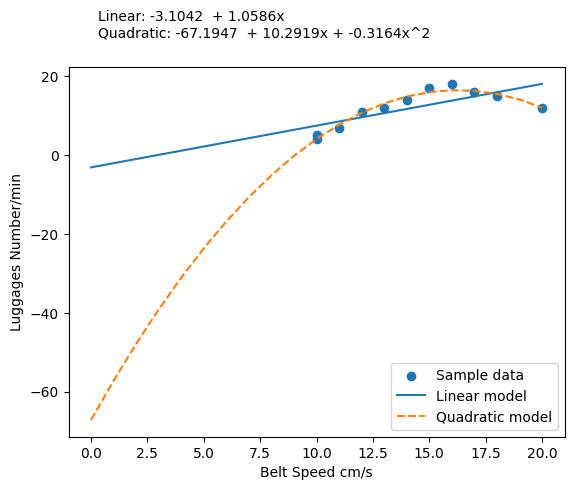

In [14]:
pLinear = np.polyfit(Speed, Luggages, 1)
eqLinear = f"Linear: {pLinear[1]:.4f}  + {pLinear[0]:.4f}x  "

pQuad = np.polyfit(Speed, Luggages, 2)
eqQuad = f"Quadratic: {pQuad[2]:.4f}  + {pQuad[1]:.4f}x + {pQuad[0]:.4f}x^2  "

xQuery = np.arange(0, 21)
yLinear = np.polyval(pLinear, xQuery)
yQuad = np.polyval(pQuad, xQuery)

plt.scatter(Speed, Luggages)
plt.plot(xQuery, yLinear, "-")
plt.plot(xQuery, yQuad, "--")

plt.xlabel("Belt Speed cm/s")
plt.ylabel("Luggages Number/min")
plt.legend(["Sample data", "Linear model", "Quadratic model"])
plt.text(0.3, 30, eqLinear + "\n" + eqQuad)
plt.show()

## For II order model find Total and Regression Sum of Squares

Here we use the centered version

$\sum (Y_i - \bar{Y})^2$.

In [15]:
SS_Total = Y.T @ Y - len(Y) * np.mean(Y)**2  #  228.9091
print(f"SS_Total {SS_Total:.2f}")
SS_Regression = beta_hat.T @ X.T @ Y - len(Y) * np.mean(Y)**2 # 221.6775
print(f"SS_Regression {SS_Regression:.2f}")

SS_Total 228.91
SS_Regression 221.68


## Calculate the  $R^2$

R2 =  Regression SSQ/Total SSQ  

R2 = (Total SSQ-Residual SSQ)/Total SSQ

R2 = 1 - (Residual SSQ/Total SSQ)

In [16]:
n = len(Y)
R2_IIorderModel = SS_Regression / SS_Total # R2 = 0.9684
print(f"R2 {R2_IIorderModel:.3f}",)

R2 0.968


## Next to find Adjusted R^2

In [17]:
p = len(beta_hat)  # 3
R2Adj_IIoderModel = 1 - (RsSSQ1 / (n - p)) / (SS_Total / (n - 1)) # R2_Adj = 0.9605
print(f"Adjusted R2 {R2Adj_IIoderModel:.3f}",)

Adjusted R2 0.961


## Find the PRESS

In [18]:
# First find H Matrices

HX = X @ np.linalg.inv(X.T @ X) @ X.T
print("HX",HX)
# Check for idempotent nature
compare_HX = np.column_stack((HX, HX @ HX))


HX [[ 0.37  0.37  0.24  0.13  0.05 -0.01 -0.05 -0.07 -0.06 -0.04  0.08]
 [ 0.37  0.37  0.24  0.13  0.05 -0.01 -0.05 -0.07 -0.06 -0.04  0.08]
 [ 0.24  0.24  0.19  0.14  0.1   0.07  0.04  0.02 -0.   -0.01 -0.02]
 [ 0.13  0.13  0.14  0.15  0.14  0.13  0.11  0.09  0.05  0.01 -0.09]
 [ 0.05  0.05  0.1   0.14  0.17  0.17  0.16  0.14  0.1   0.04 -0.12]
 [-0.01 -0.01  0.07  0.13  0.17  0.19  0.19  0.17  0.13  0.07 -0.11]
 [-0.05 -0.05  0.04  0.11  0.16  0.19  0.2   0.19  0.16  0.11 -0.07]
 [-0.07 -0.07  0.02  0.09  0.14  0.17  0.19  0.19  0.18  0.14  0.02]
 [-0.06 -0.06 -0.    0.05  0.1   0.13  0.16  0.18  0.18  0.18  0.15]
 [-0.04 -0.04 -0.01  0.01  0.04  0.07  0.11  0.14  0.18  0.22  0.32]
 [ 0.08  0.08 -0.02 -0.09 -0.12 -0.11 -0.07  0.02  0.15  0.32  0.77]]


In [19]:
PRESS_X = 0.0

Res_SSQ2_X = 0

for i in range(len(Y)):
    Res_SSQ2_X = Res_SSQ2_X + (Y[i] - Y_Pred[i])**2

    # PRESS Calculations

    PRESS_X = PRESS_X + ((Y[i] - Y_Pred[i]) / (1 - HX[i, i]))**2
print(f"PRESS X {PRESS_X:.3f}")


PRESS X 11.936


## Find R2 PRESS

In [20]:
R2_PRESS = 1 - PRESS_X / (Y.T @ Y - n * (np.mean(Y))**2)
print("R2 PRESS",R2_PRESS)

R2 PRESS 0.9478566007969111


## Find the variance covariance matrix

In [21]:
VarCov_Matrix = (np.linalg.inv(X.T @ X)) * (RsSSQ1 / (n - p))
print("variance covariance matrix",VarCov_Matrix)

## Get the variance that is the diagonal elements
Var_BetaHat = np.diag(np.diag(VarCov_Matrix))
print("Variance Hat",Var_BetaHat)

variance covariance matrix [[40.16 -5.65  0.19]
 [-5.65  0.81 -0.03]
 [ 0.19 -0.03  0.  ]]
Variance Hat [[40.16  0.    0.  ]
 [ 0.    0.81  0.  ]
 [ 0.    0.    0.  ]]


In [22]:
# standard error
StdError_Beta = np.sqrt(Var_BetaHat)
print("StdError_Beta",StdError_Beta)

StdError_Beta [[6.34 0.   0.  ]
 [0.   0.9  0.  ]
 [0.   0.   0.03]]


# Problem 2 housing price prediction

In [23]:
# Load the data from the excel sheet "Housing_Use.xlsx"
df = pd.read_excel(os.path.join('/content','Housing_Use.xlsx'),sheet_name='Housing')
## Drop rows with nan (the late two rows have artifacts like `Count`)
df = df.dropna()
## Convert the data to a numpy array
Data = df.values

## Correlation plot

Note: this code cell will take time to complete execution.

/tmp/ipykernel_10908/43896628.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_10908/43896628.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_10908/43896628.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_10908/43896628.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_10908/43896628.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks,

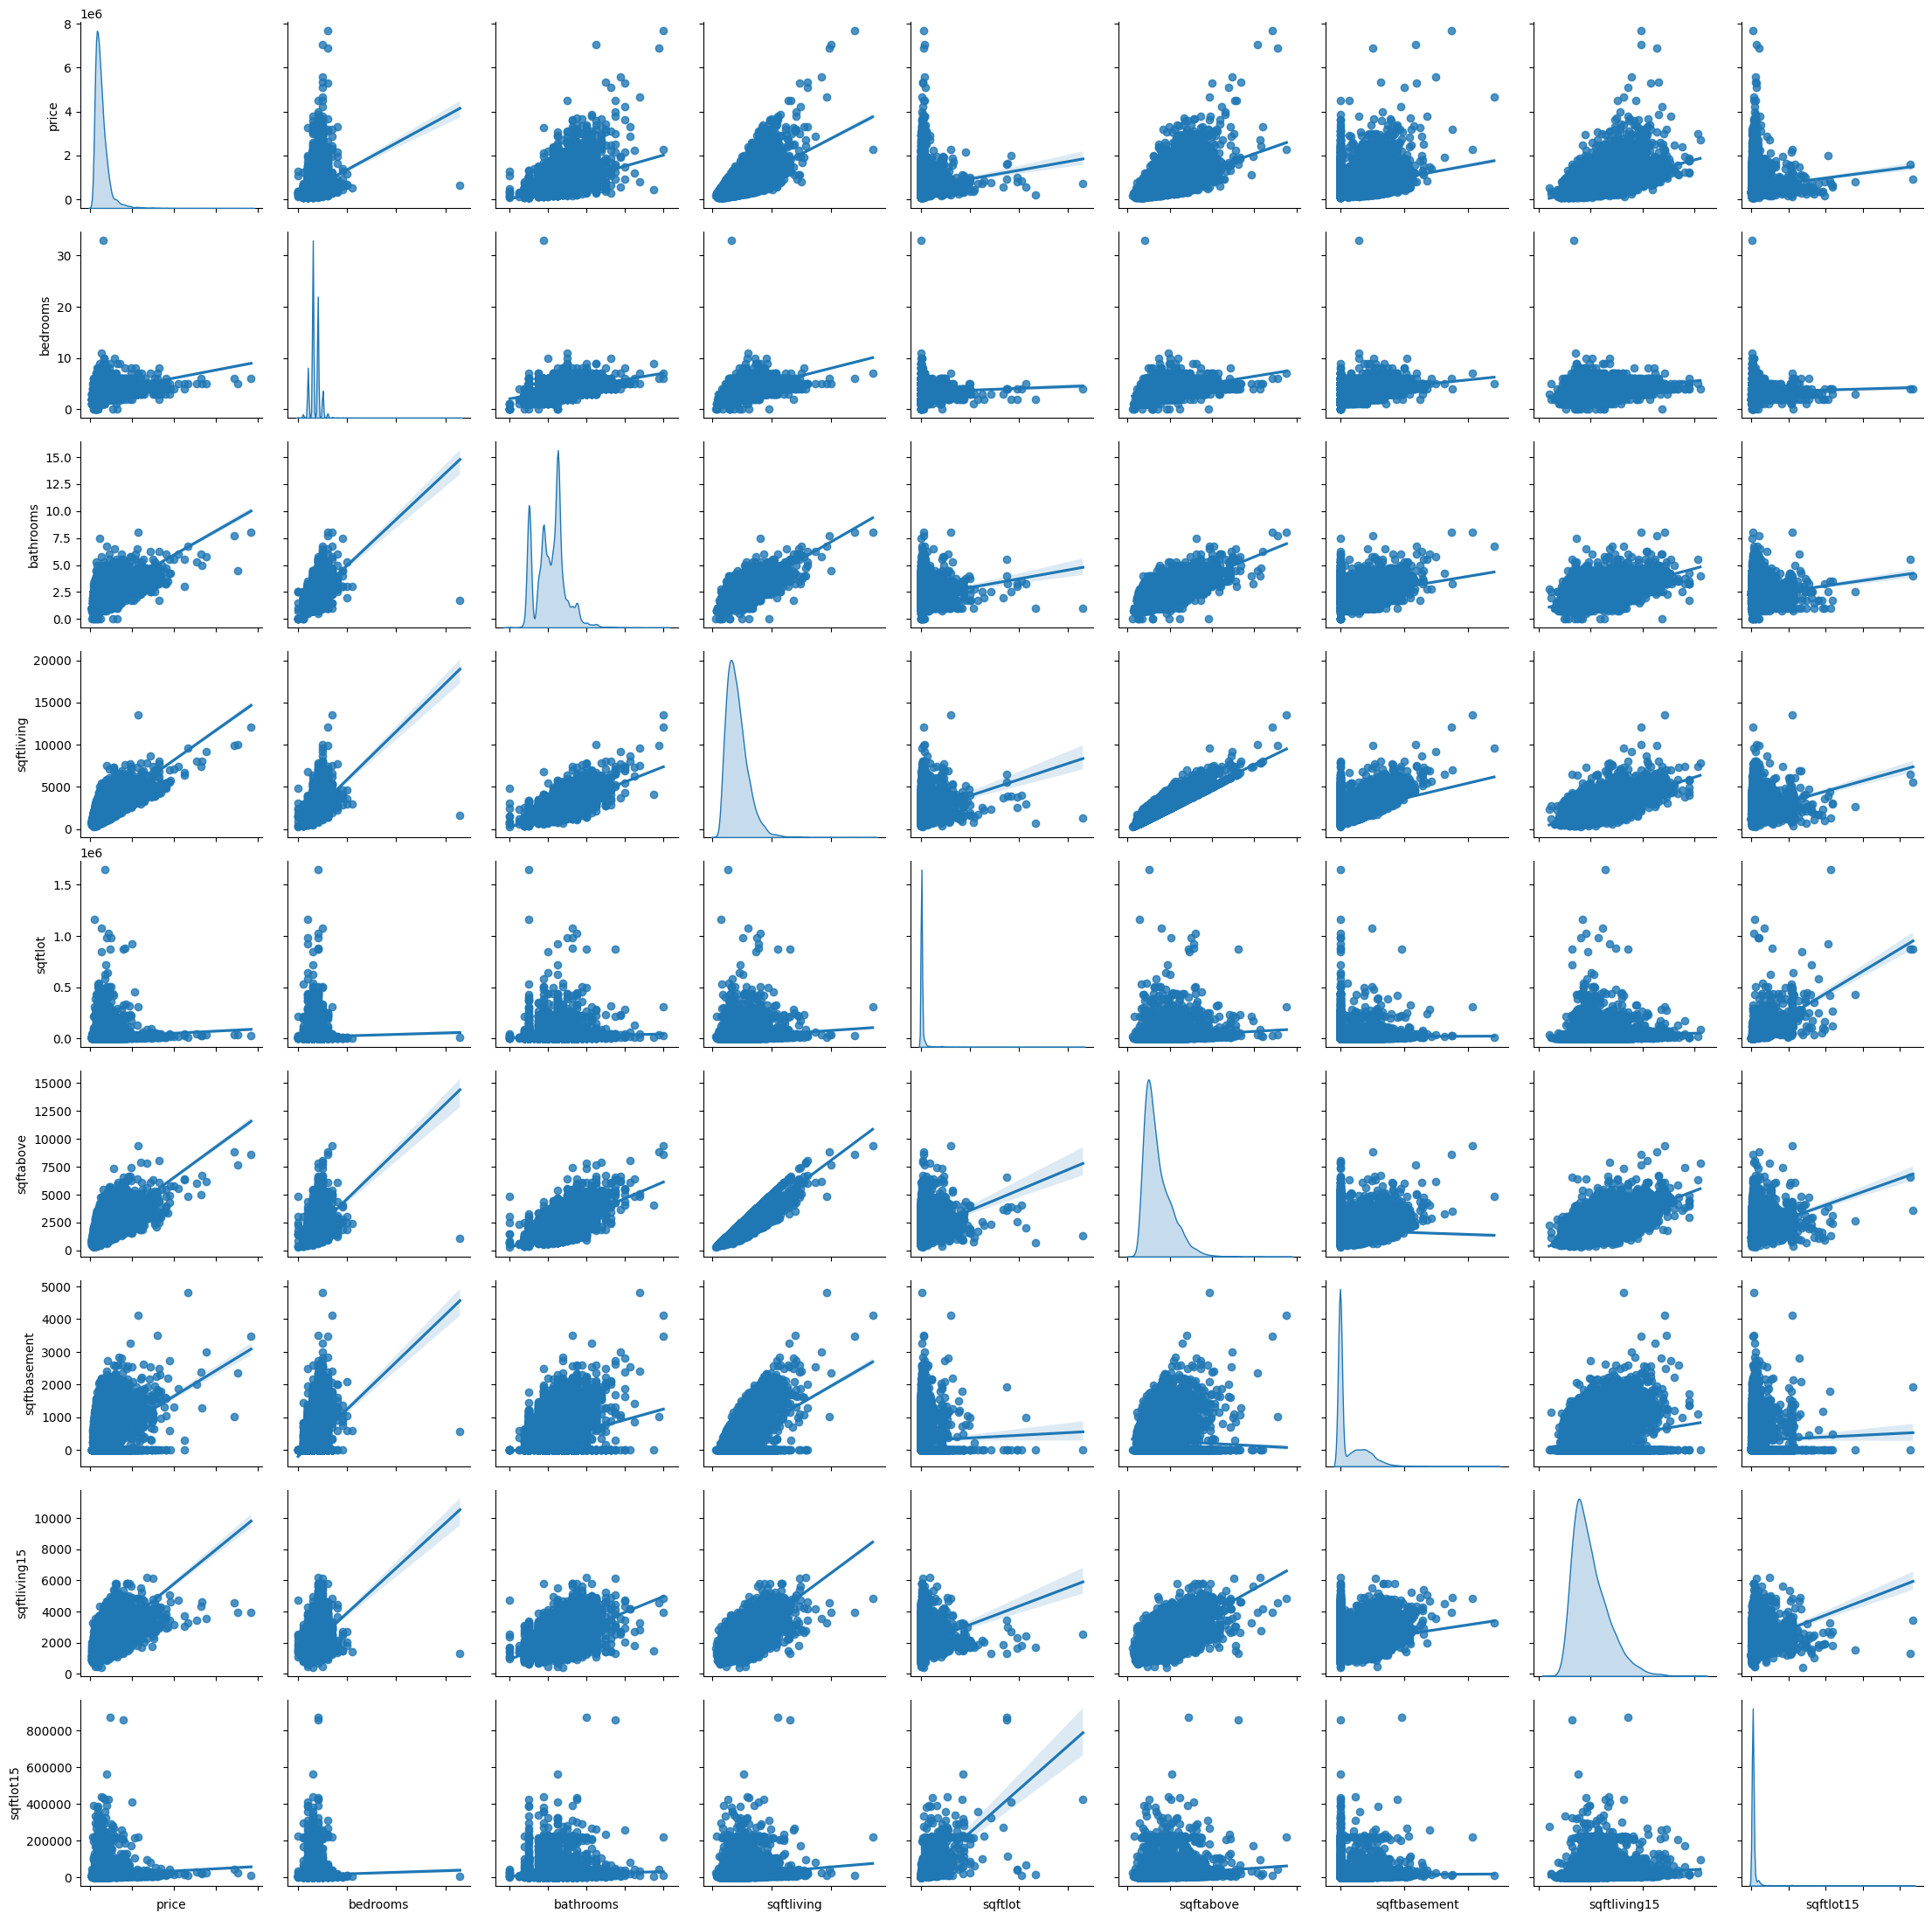

In [ ]:
Tbl = pd.DataFrame(Data, columns=['price', 'bedrooms', 'bathrooms', 'sqftliving', 'sqftlot', 'sqftabove', 'sqftbasement', 'sqftliving15', 'sqftlot15'])

# Convert all columns to numeric, coercing errors to NaN
for col in Tbl.columns:
    Tbl[col] = pd.to_numeric(Tbl[col], errors='coerce')

# Drop rows that contain any NaN values after conversion
Tbl = Tbl.dropna()

# Generate the pairplot with regression lines
g = sns.pairplot(Tbl, kind='reg', diag_kind='kde', height=2.5)


for ax in g.axes.flat:
    if ax is not None:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

## Normalize the data

In [24]:
Y = Data[:, 0] / 1e6 # Scaling the data in terms of millions of dollars
X1 = Data[:, 1]
X2 = Data[:, 2]
X3 = Data[:, 3]
X4 = Data[:, 4]
X5 = Data[:, 5]
X6 = Data[:, 6]
X7 = Data[:, 7]
X8 = Data[:, 8]

val = Data.shape

# Define the feature matrix and target variable
Features = np.column_stack((X1, X2, X3, X4, X5, X6, X7, X8))
Features = Features.astype(float)

X_Normalized = (Features - np.mean(Features, axis=0)) / np.std(Features, axis=0, ddof=1)

Target = Y  # Express house price in millions of dollars
Data_Norm_All = np.column_stack((Target, X_Normalized)) # Scaled Target and Features

Tb2 = pd.DataFrame(Data_Norm_All, columns=['Y', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'])



## The X matrix

In [25]:
# Constructing the Big X matrix

# Data_Norm =  [normalize(X1), normalize(X2), normalize(X3), normalize(X4), normalize(X5), normalize(X6), normalize(X7), normalize(X8)]; # No Target

# Remove X5 as including it made the X matrix nearly singular

X1_n = (Features[:, 0] - np.mean(Features[:, 0])) / np.std(Features[:, 0], ddof=1)
X2_n = (Features[:, 1] - np.mean(Features[:, 1])) / np.std(Features[:, 1], ddof=1)
X3_n = (Features[:, 2] - np.mean(Features[:, 2])) / np.std(Features[:, 2], ddof=1)
X4_n = (Features[:, 3] - np.mean(Features[:, 3])) / np.std(Features[:, 3], ddof=1)
# Skipping the 5th column
X6_n = (Features[:, 5] - np.mean(Features[:, 5])) / np.std(Features[:, 5], ddof=1)
X7_n = (Features[:, 6] - np.mean(Features[:, 6])) / np.std(Features[:, 6], ddof=1)
X8_n = (Features[:, 7] - np.mean(Features[:, 7])) / np.std(Features[:, 7], ddof=1)

Data_Norm = np.column_stack((X1_n, X2_n, X3_n, X4_n, X6_n, X7_n, X8_n)) # No Target

X = np.column_stack((np.ones(val[0]), Data_Norm))

## Estimate the $\hat{\beta}$

In [26]:
beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ Y)

print("Beta Hat:")
print(beta_hat)
print("\n")

Beta Hat:
[0.5400885766899534 -0.05447789283038358 0.005708895153345873
 0.24400342866591626 0.0018297784812846968 0.01820996468130612
 0.04890346222877398 -0.023945812426574536]




## Calculate the predicted values using the estimated coefficients

In [27]:

Predicted_Prices = X @ beta_hat
Compare = np.column_stack((Y, Predicted_Prices))
print("Compare (First 5 rows):")
print(Compare[:5, :])
print("\n")

Compare (First 5 rows):
[[0.2313 0.3207362497057549]
 [0.538 0.6804704563684901]
 [0.18 0.30835243013124136]
 [0.604 0.4650522944120617]
 [0.51 0.43371653910570307]]




## R-square calculation

In [28]:
# Total Sum of Squares
SST = np.sum((Y - np.mean(Y))**2)
print(f"SST {SST:.2f}")
# Residual Sum of Squares
SSE = np.sum((Y - Predicted_Prices)**2)
print(f"SSE {SSE:.2f}")
# Regression Sum of Squares
SSR = np.sum((Predicted_Prices - np.mean(Y))**2)
print(f"SSR {SSR:.2f}")
# R-square
R2 = 1 - (SSE / SST)

print(f'R-square: {R2:.2f}')


SST 2912.91
SSE 1403.71
SSR 1509.20
R-square: 0.52


# Adjusted R-square

In [29]:
n = len(Y)      # Number of observations
p = X.shape[1] - 1  # Number of predictors

Adj_R2 = 1 - ((SSE/(n-p-1)) / (SST/(n-1)))

print('Adjusted R-square:')
print(Adj_R2)

Adjusted R-square:
0.5179497662188426
